# Importing

## Import Library

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('./e-commerce-behavior-eda.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Import CSV And convert to DataFrame

In [5]:
df = pd.read_csv('ecommerce_user_behavior_8000.csv')

# Preprocessing

## Frist five row

In [6]:
df.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


## last Five row

In [7]:
df.tail()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
7995,7996.0,48.0,Female,Tablet,2.67,10.0,6.0,0.0,1.0,0.0,1.0,3.01,82.44,1.0
7996,7997.0,54.0,Male,Mobile,18.94,13.0,11.0,4.0,1.0,1.0,1.0,27.48,10.06,1.0
7997,7998.0,54.0,Female,Desktop,24.08,8.0,13.0,1.0,0.0,0.0,1.0,27.57,21.34,1.0
7998,7999.0,32.0,Female,Mobile,10.85,13.0,12.0,8.0,1.0,1.0,0.0,5.78,2.03,1.0
7999,8000.0,46.0,Female,Mobile,12.23,2.0,9.0,2.0,0.0,1.0,1.0,8.28,15.67,1.0


## Shape of our dataset

In [8]:
df.shape

(8000, 14)

## List out all columns

In [9]:
df.columns

Index(['user_id', 'age', 'gender', 'device_type', 'time_on_site',
       'pages_viewed', 'previous_purchases', 'cart_items', 'discount_seen',
       'ad_clicked', 'returning_user', 'avg_session_time', 'bounce_rate',
       'purchase'],
      dtype='str')

## Datatype of each columns

In [10]:
df.dtypes

user_id               float64
age                   float64
gender                    str
device_type               str
time_on_site          float64
pages_viewed          float64
previous_purchases    float64
cart_items            float64
discount_seen         float64
ad_clicked            float64
returning_user        float64
avg_session_time      float64
bounce_rate           float64
purchase              float64
dtype: object

## Information of all Columns

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             7840 non-null   float64
 1   age                 7840 non-null   float64
 2   gender              7840 non-null   str    
 3   device_type         7840 non-null   str    
 4   time_on_site        7840 non-null   float64
 5   pages_viewed        7840 non-null   float64
 6   previous_purchases  7840 non-null   float64
 7   cart_items          7840 non-null   float64
 8   discount_seen       7840 non-null   float64
 9   ad_clicked          7840 non-null   float64
 10  returning_user      7840 non-null   float64
 11  avg_session_time    7840 non-null   float64
 12  bounce_rate         7840 non-null   float64
 13  purchase            7840 non-null   float64
dtypes: float64(12), str(2)
memory usage: 875.1 KB


## Check Null Value

In [12]:
df.isnull().sum()

user_id               160
age                   160
gender                160
device_type           160
time_on_site          160
pages_viewed          160
previous_purchases    160
cart_items            160
discount_seen         160
ad_clicked            160
returning_user        160
avg_session_time      160
bounce_rate           160
purchase              160
dtype: int64

## Separate numerical and categorical columns

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

## Fill missing values in numerical columns using MEAN

In [14]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

## Fill missing values in categorical columns using MODE

In [15]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## Check if any null values still exist

In [16]:
print(df.isnull().sum().sum())

2240


## Check Dupicate Value

In [17]:
df.duplicated().sum()

np.int64(0)

## Summary

In [18]:
df.describe()

,user_id,age,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
count,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000
mean,4003.135077,38.595791,15.714673,9.970026,6.964158,4.530230,0.502551,0.502296,0.509439,15.794999,49.924402,0.998342
std,2307.898984,12.033928,8.362764,5.425485,4.281117,2.865814,0.500025,0.500027,0.499943,9.864556,29.137449,0.040689
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.570000,0.010000,0.000000
25%,2011.750000,28.000000,8.520000,5.000000,3.000000,2.000000,0.000000,0.000000,0.000000,7.750000,24.677500,1.000000
50%,3998.000000,39.000000,15.740000,10.000000,7.000000,5.000000,1.000000,1.000000,1.000000,14.300000,49.500000,1.000000
75%,6001.250000,49.000000,22.880000,15.000000,11.000000,7.000000,1.000000,1.000000,1.000000,22.392500,75.990000,1.000000
max,8000.000000,59.000000,30.000000,19.000000,14.000000,9.000000,1.000000,1.000000,1.000000,44.750000,99.970000,1.000000


# EDA

In [19]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

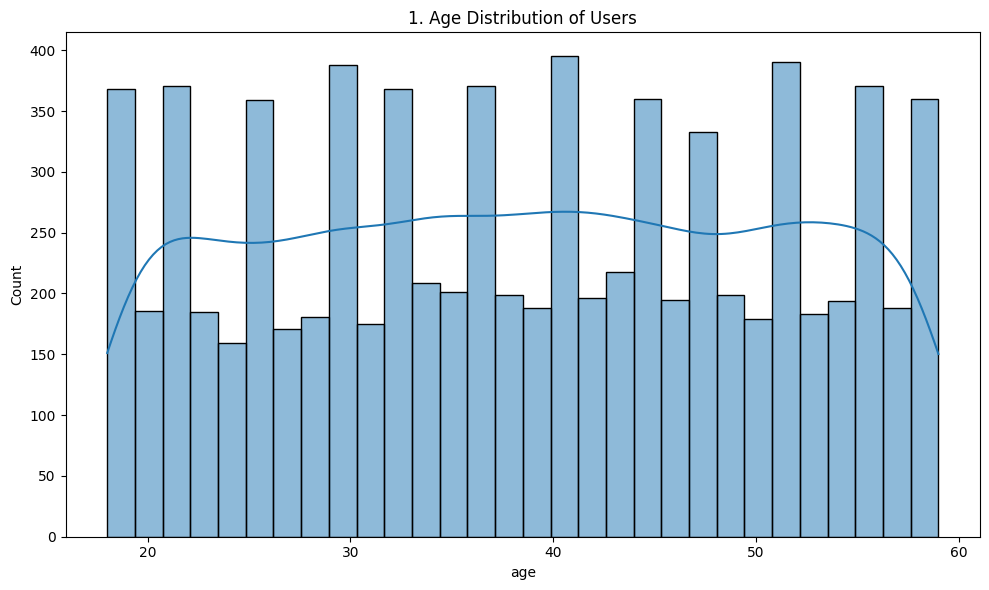

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title(f'{plot_no}. Age Distribution of Users')
show_fig()
plot_no += 1

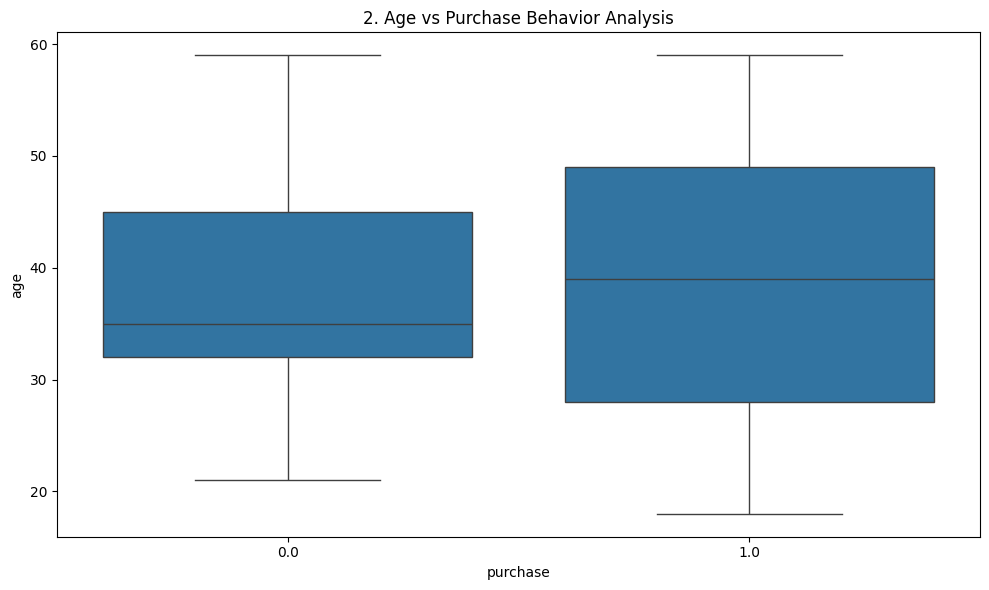

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='purchase', y='age', data=df)
plt.title(f'{plot_no}. Age vs Purchase Behavior Analysis')
show_fig()
plot_no += 1

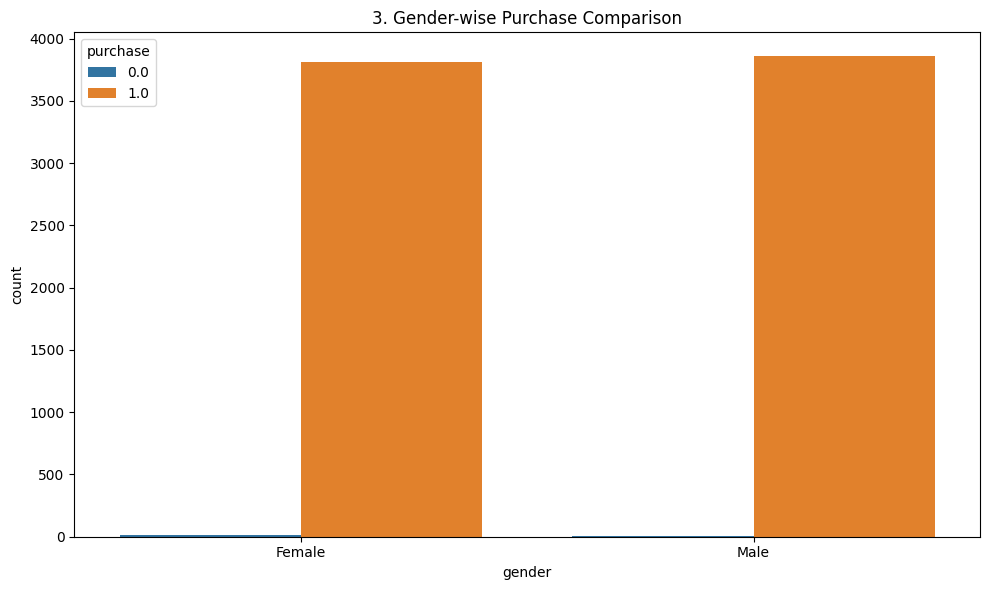

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='gender', hue='purchase', data=df)
plt.title(f'{plot_no}. Gender-wise Purchase Comparison')
show_fig()
plot_no += 1

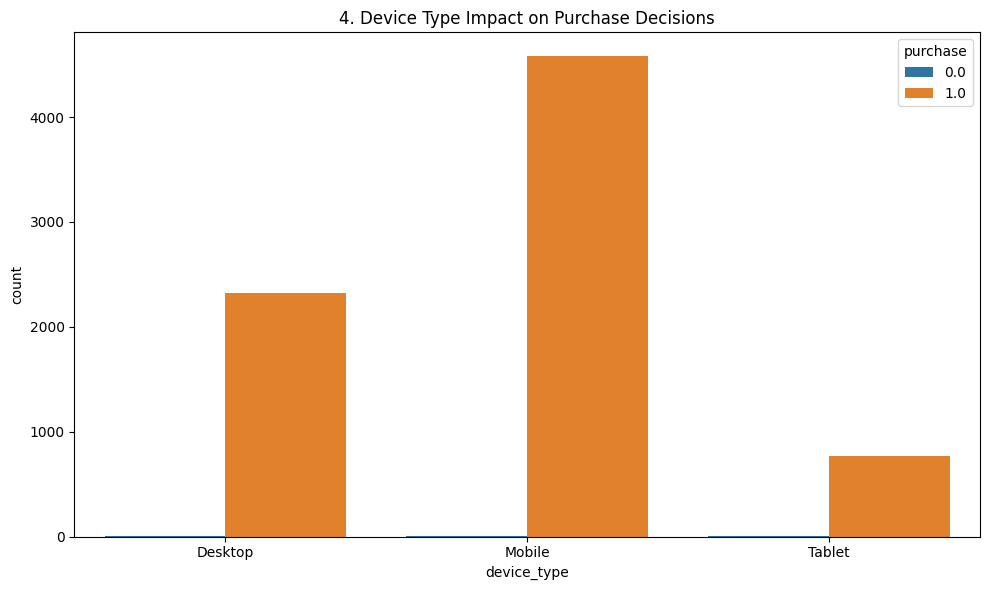

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='device_type', hue='purchase', data=df)
plt.title(f'{plot_no}. Device Type Impact on Purchase Decisions')
show_fig()
plot_no += 1

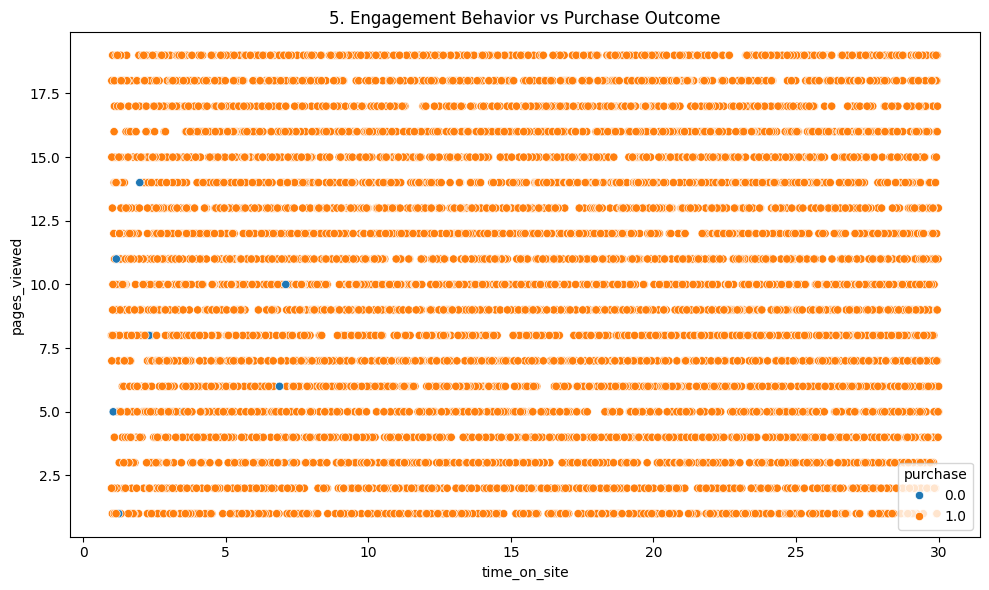

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='time_on_site', y='pages_viewed', hue='purchase', data=df)
plt.title(f'{plot_no}. Engagement Behavior vs Purchase Outcome')
show_fig()
plot_no += 1

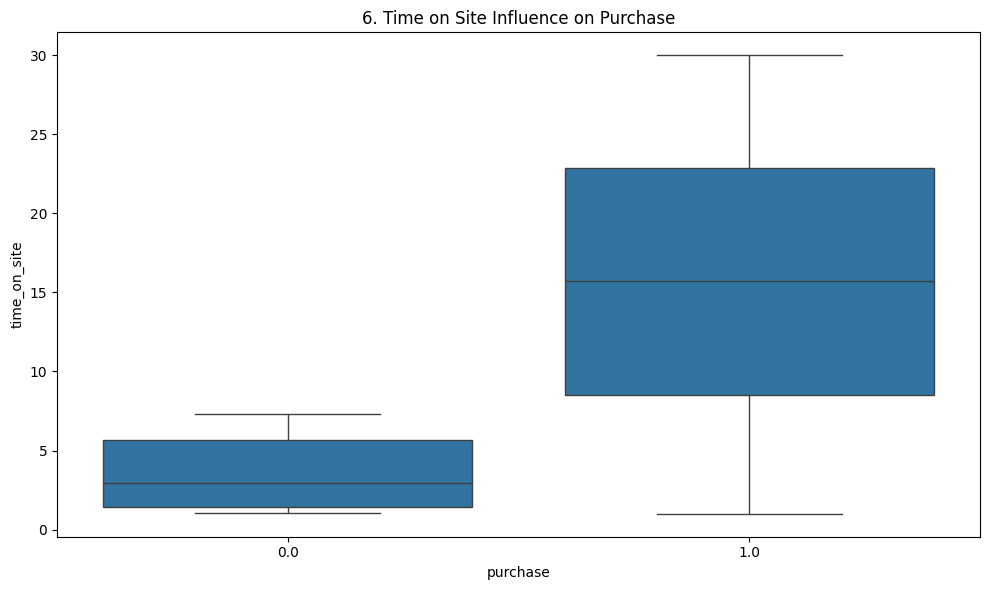

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='purchase', y='time_on_site', data=df)
plt.title(f'{plot_no}. Time on Site Influence on Purchase')
show_fig()
plot_no += 1

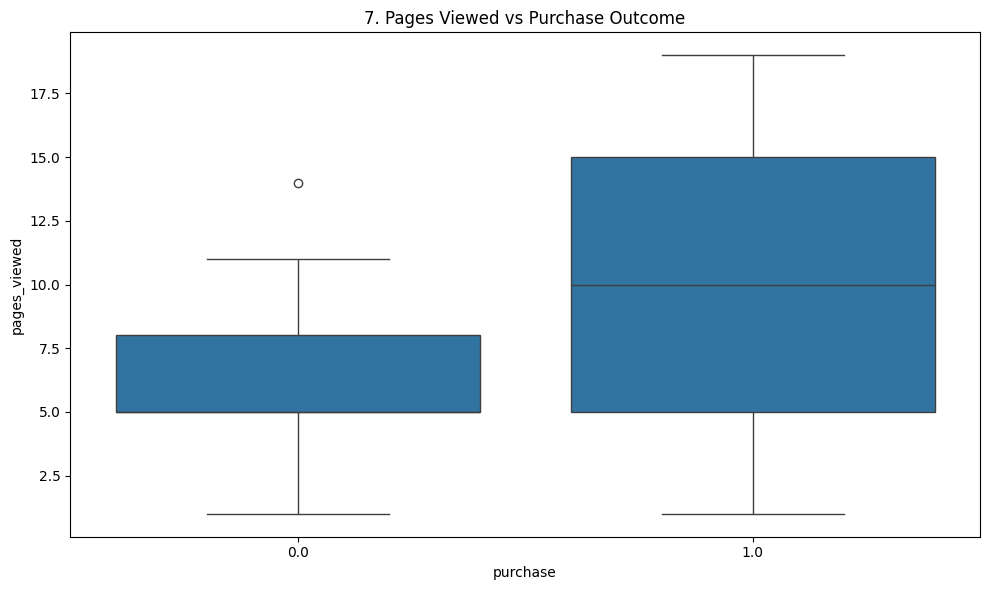

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='purchase', y='pages_viewed', data=df)
plt.title(f'{plot_no}. Pages Viewed vs Purchase Outcome')
show_fig()
plot_no += 1

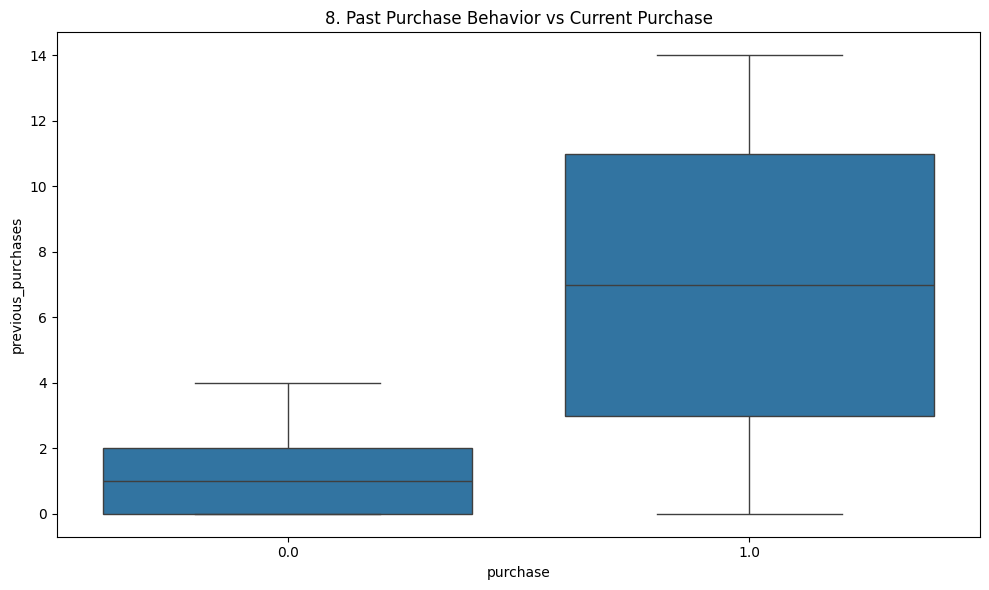

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='purchase', y='previous_purchases', data=df)
plt.title(f'{plot_no}. Past Purchase Behavior vs Current Purchase')
show_fig()
plot_no += 1

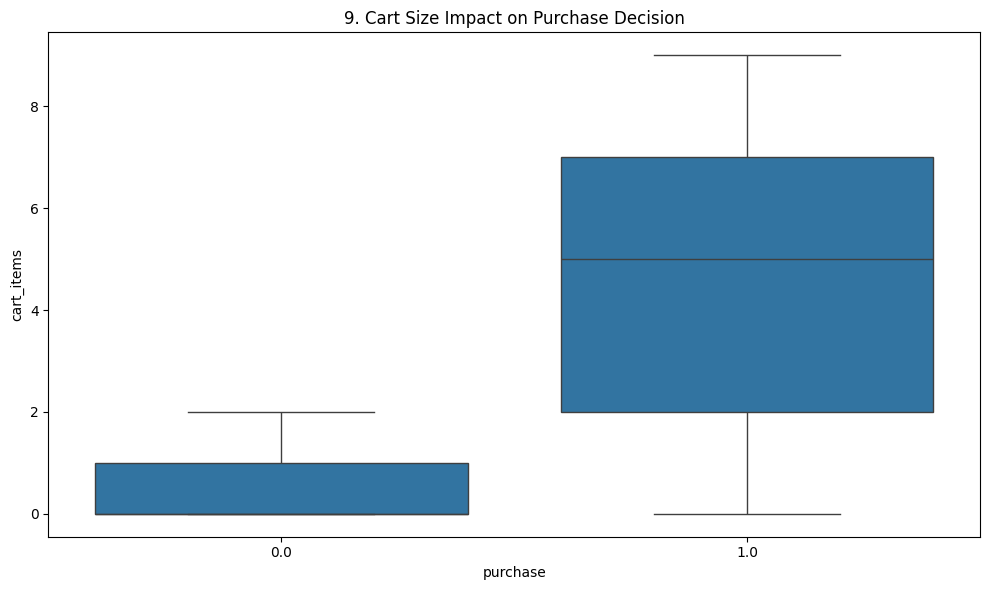

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='purchase', y='cart_items', data=df)
plt.title(f'{plot_no}. Cart Size Impact on Purchase Decision')
show_fig()
plot_no += 1

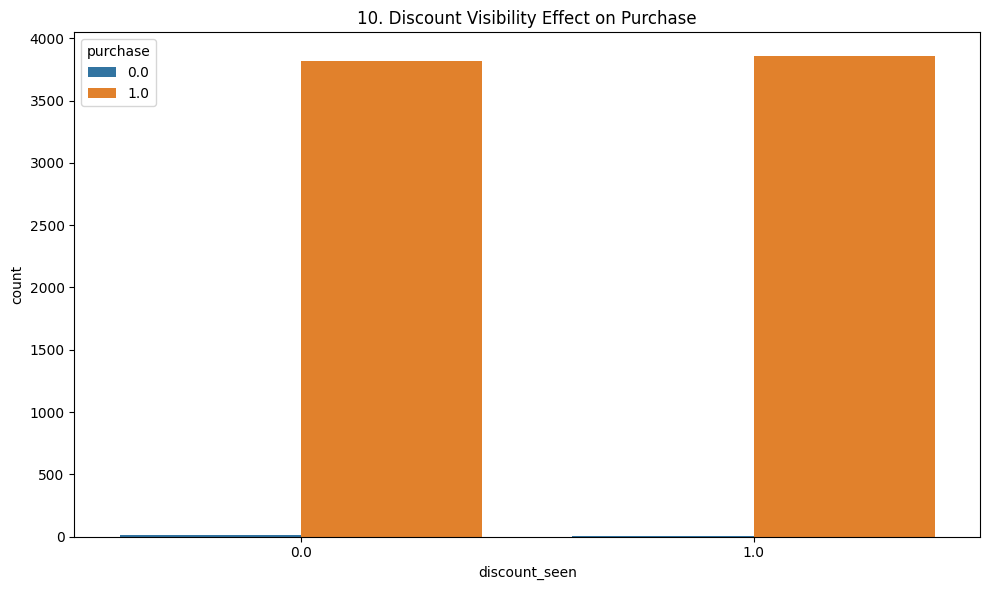

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='discount_seen', hue='purchase', data=df)
plt.title(f'{plot_no}. Discount Visibility Effect on Purchase')
show_fig()
plot_no += 1

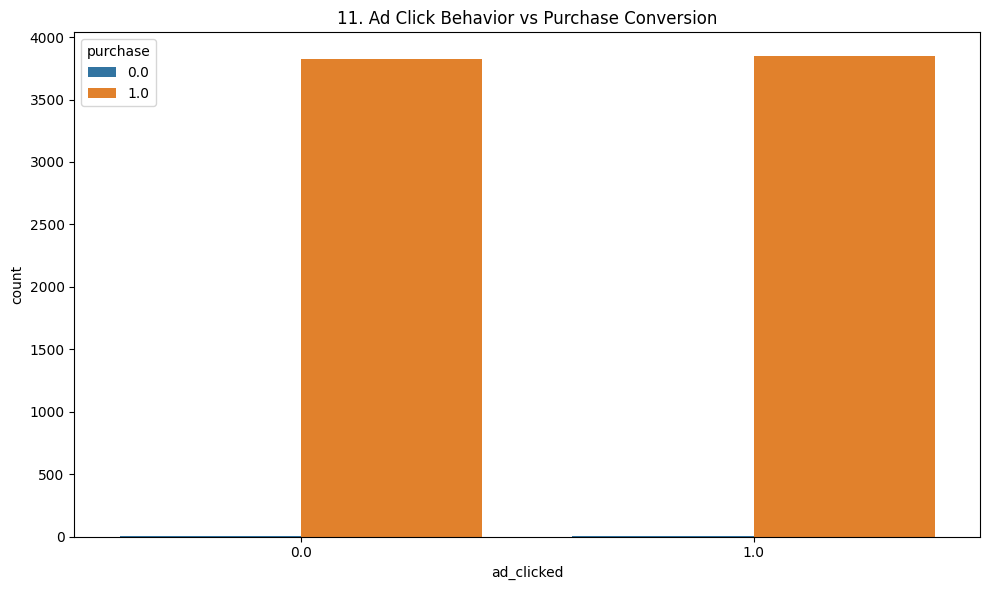

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='ad_clicked', hue='purchase', data=df)
plt.title(f'{plot_no}. Ad Click Behavior vs Purchase Conversion')
show_fig()
plot_no += 1

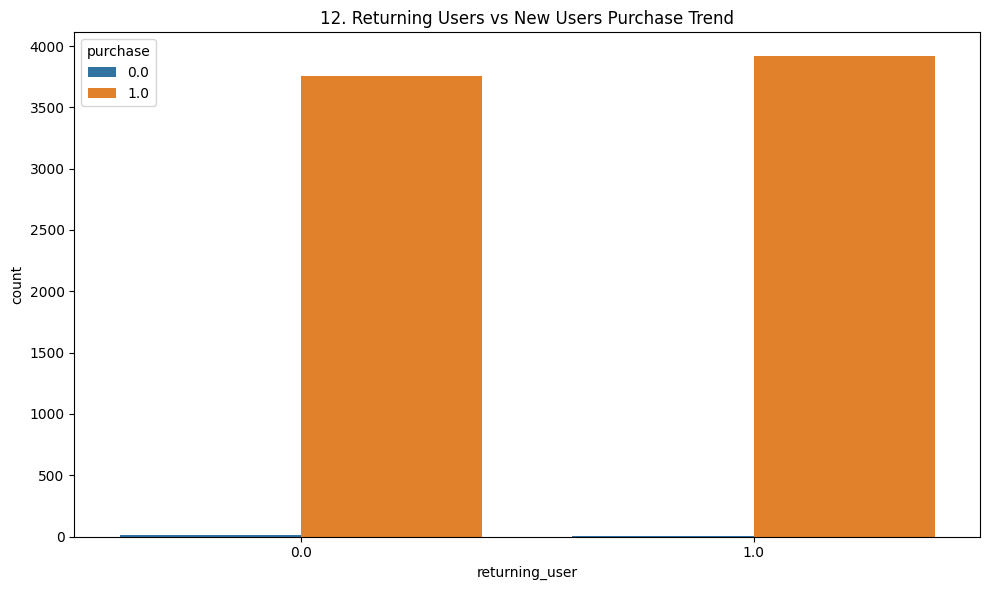

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='returning_user', hue='purchase', data=df)
plt.title(f'{plot_no}. Returning Users vs New Users Purchase Trend')
show_fig()
plot_no += 1

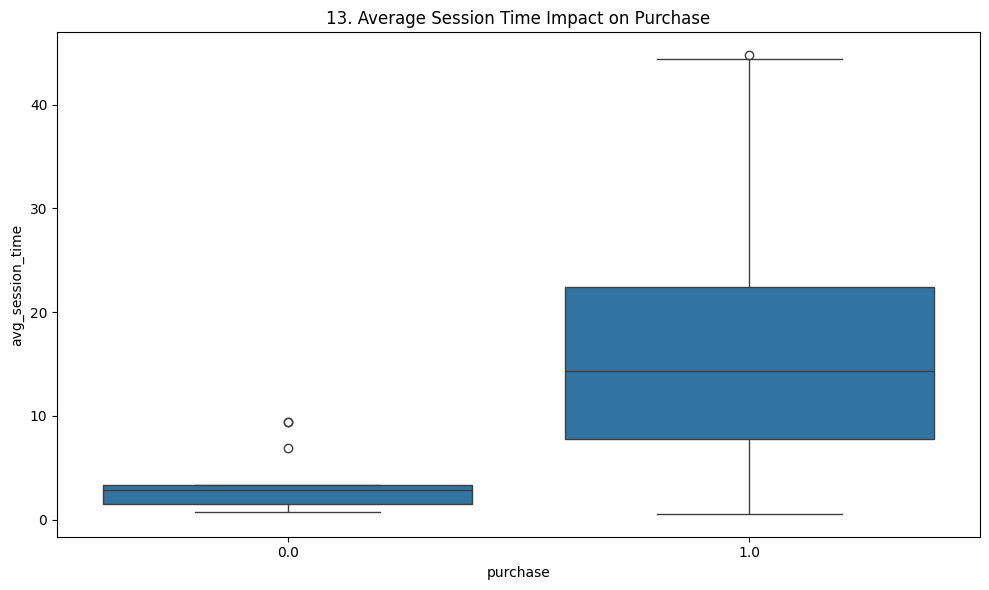

In [32]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='purchase', y='avg_session_time', data=df)
plt.title(f'{plot_no}. Average Session Time Impact on Purchase')
show_fig()
plot_no += 1

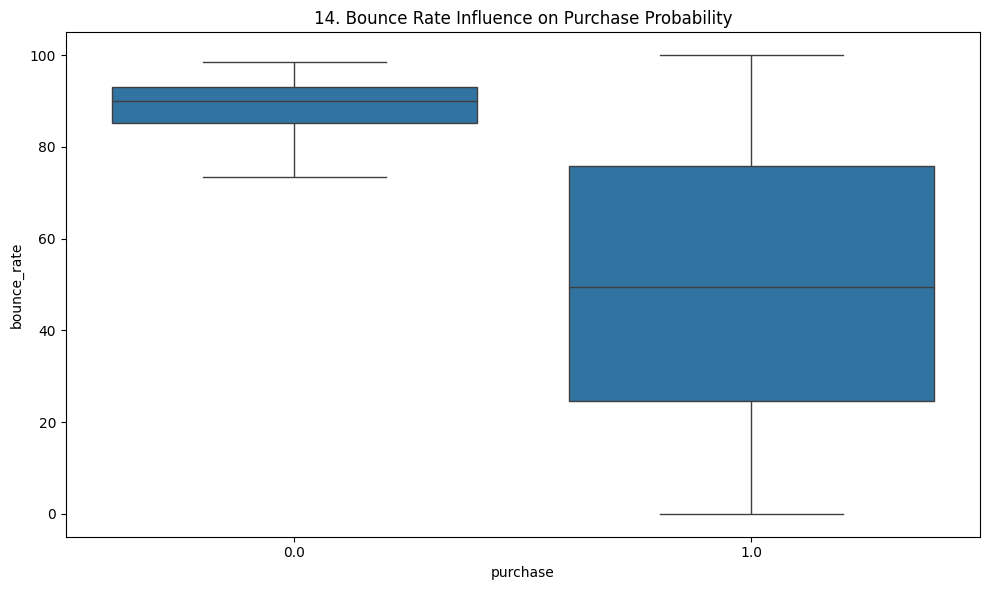

In [33]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='purchase', y='bounce_rate', data=df)
plt.title(f'{plot_no}. Bounce Rate Influence on Purchase Probability')
show_fig()
plot_no += 1

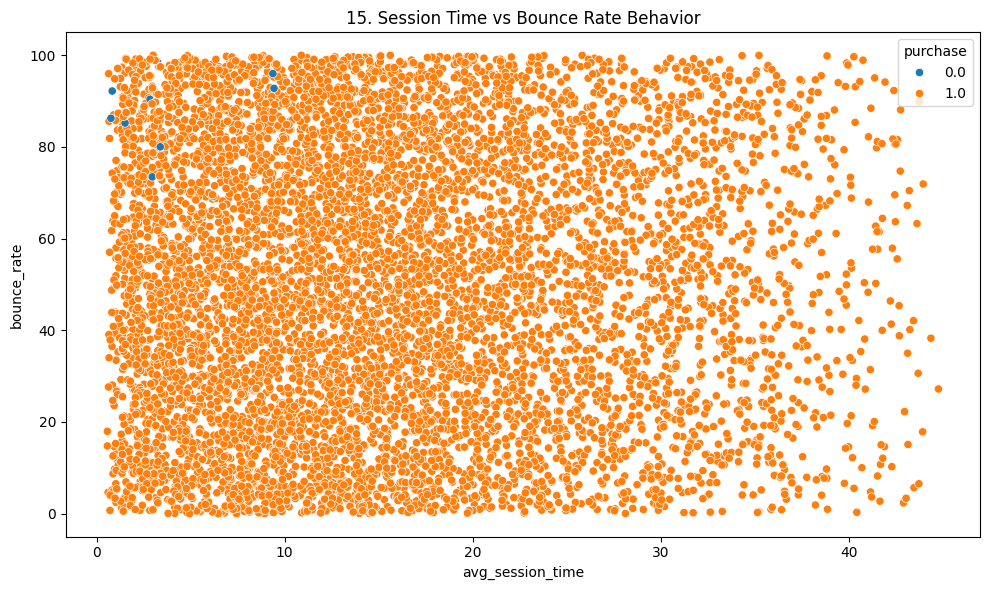

In [34]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='avg_session_time', y='bounce_rate', hue='purchase', data=df)
plt.title(f'{plot_no}. Session Time vs Bounce Rate Behavior')
show_fig()
plot_no += 1

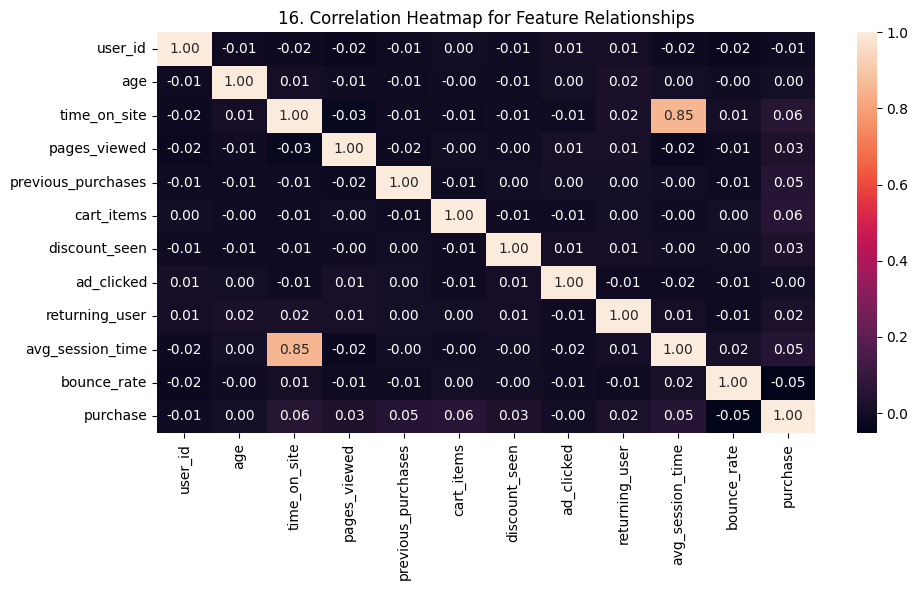

In [35]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap for Feature Relationships')
show_fig()
plot_no += 1

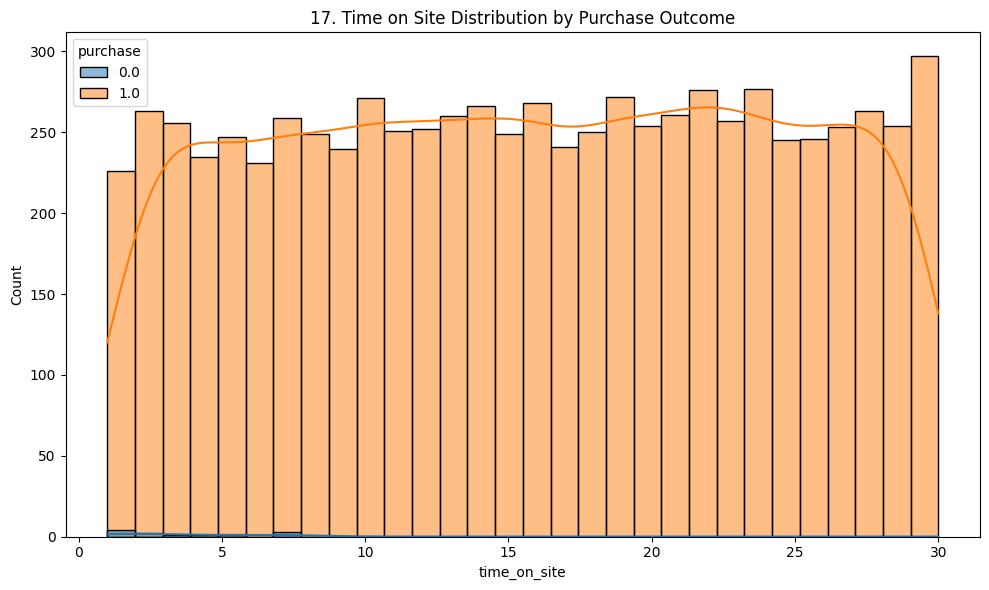

In [36]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='time_on_site', hue='purchase', bins=30, kde=True)
plt.title(f'{plot_no}. Time on Site Distribution by Purchase Outcome')
show_fig()
plot_no += 1

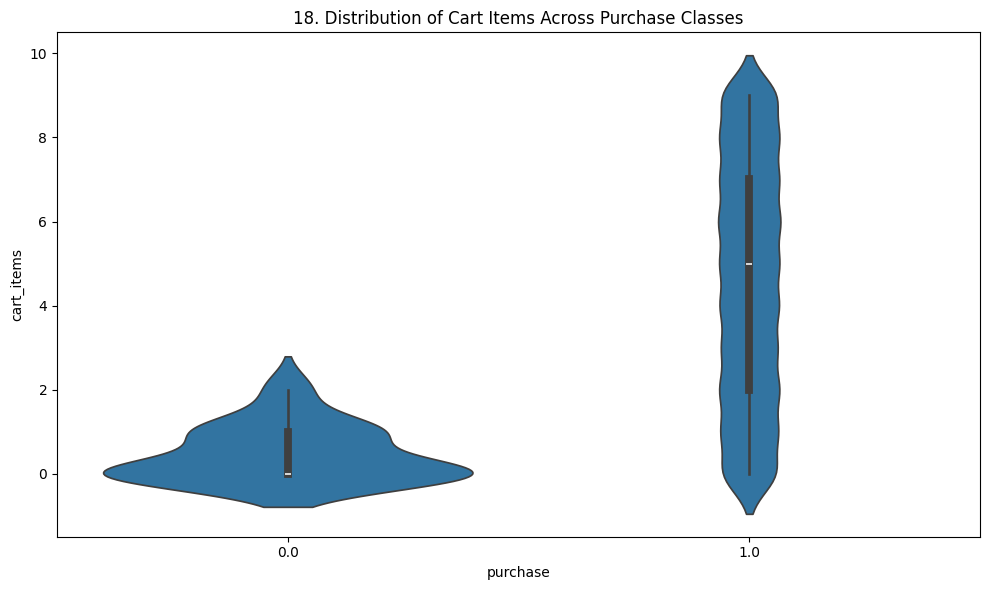

In [37]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='purchase', y='cart_items', data=df)
plt.title(f'{plot_no}. Distribution of Cart Items Across Purchase Classes')
show_fig()
plot_no += 1

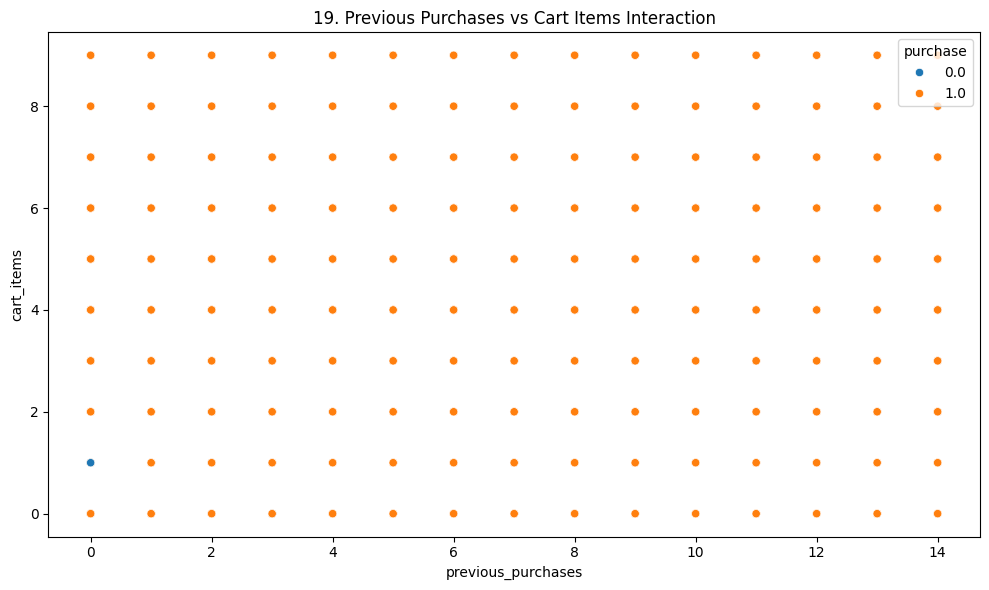

In [38]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='previous_purchases', y='cart_items', hue='purchase', data=df)
plt.title(f'{plot_no}. Previous Purchases vs Cart Items Interaction')
show_fig()
plot_no += 1